In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def inspect_and_unpack_hdf5(file_path):
    """
    Opens an HDF5 file, prints its structure if keys are unknown,
    and attempts to extract waveform data.
    """
    print(f"Opening: {file_path}\n" + "="*40)
    
    with h5py.File(file_path, 'r') as f:
        # 1. Helper function to recursively print the tree structure
        def print_structure(name, obj):
            indent = "  " * name.count('/')
            if isinstance(obj, h5py.Dataset):
                print(f"{indent}📄 Dataset: {name} (shape={obj.shape}, dtype={obj.dtype})")
                # Print a sneak peek if it's a small attribute or metadata
                if obj.ndim == 0: 
                    print(f"{indent}   Value: {obj[()]}")
            elif isinstance(obj, h5py.Group):
                print(f"{indent}📁 Group: {name}")

        print("--- File Structure & Keys ---")
        f.visititems(print_structure)
        print("="*40)

        # 2. Attempt to unpack data based on common oscilloscope structures
        # (We try a few common key guesses, but rely on your feedback if they fail)
        try:
            waveform_data = None
            time_data = None
            
            # Guessing Strategy A: Look for obvious datasets at root or in common groups
            possible_data_keys = ['waveform', 'wfm', 'data', 'Channel 1', 'CH1/YDATA', 'Volt']
            possible_time_keys = ['time', 't', 'CH1/XDATA', 'Time']
            
            for k in f.keys():
                if any(x.lower() in k.lower() for x in possible_data_keys):
                    if isinstance(f[k], h5py.Dataset):
                        waveform_data = f[k][:]
                        print(f"Found potential waveform dataset in key: '{k}'")
            
            # If we found data but no explicit time vector, look for metadata (dt, sampling rate)
            if waveform_data is not None:
                print("\nSuccessfully unpacked raw dataset!")
                # Return the data and the file object's keys for context
                return waveform_data
            
            print("\nCould not automatically map the waveform keys. Please inspect the printout above.")
            return None

        except Exception as e:
            print(f"\nAn error occurred while trying to parse: {e}")
            return None

# --- RUNNING THE CODE ---
# Replace 'your_oscilloscope_file.h5' with your actual filename
file_path = r"ffch_data_july2026\q1ch0_const.HDF5" 

# Run the unpacker
data = inspect_and_unpack_hdf5(file_path)

# If data was successfully grabbed, you can plot it here
if data is not None:
    print(f"Data shape: {data.shape}")
    # plt.plot(data)
    # plt.show()

Opening: ffch_data_july2026\q1ch0_const.HDF5
--- File Structure & Keys ---
📁 Group: __BV_Dataset__Data__
  📁 Group: __BV_Dataset__Data__/data_chan3_capture1
    📄 Dataset: __BV_Dataset__Data__/data_chan3_capture1/___BV___CUSTOM_DOUBLE_METADATA__MaxBandwidth (shape=(1,), dtype=float64)
    📄 Dataset: __BV_Dataset__Data__/data_chan3_capture1/___BV___CUSTOM_DOUBLE_METADATA__MinBandwidth (shape=(1,), dtype=float64)
    📄 Dataset: __BV_Dataset__Data__/data_chan3_capture1/___BV___CUSTOM_DOUBLE_METADATA__XDisplayOrigin (shape=(1,), dtype=float64)
    📄 Dataset: __BV_Dataset__Data__/data_chan3_capture1/___BV___CUSTOM_DOUBLE_METADATA__XDisplayRange (shape=(1,), dtype=float64)
    📄 Dataset: __BV_Dataset__Data__/data_chan3_capture1/___BV___CUSTOM_DOUBLE_METADATA__XIncrement (shape=(1,), dtype=float64)
    📄 Dataset: __BV_Dataset__Data__/data_chan3_capture1/___BV___CUSTOM_DOUBLE_METADATA__XOrigin (shape=(1,), dtype=float64)
    📄 Dataset: __BV_Dataset__Data__/data_chan3_capture1/___BV___CUSTOM_DO

In [2]:
with h5py.File(file_path, 'r') as f:
    print(f['__BV_Dataset__Data__/xdata_chan/BVAxisLabel'][0].decode('utf-8'))
    print(f['__BV_Dataset__Data__/xdata_chan/BVAxisUnitLabel'][0].decode('utf-8'))

Time
s


In [1]:
import h5py
import numpy as np
from pathlib import Path

# --- Conversion tables to canonical units (ns for time, mV for voltage) ---
_TIME_TO_NS = {
    "s": 1e9, "sec": 1e9, "second": 1e9, "seconds": 1e9,
    "ms": 1e6, "millisecond": 1e6, "milliseconds": 1e6,
    "us": 1e3, "usec": 1e3, "microsecond": 1e3, "microseconds": 1e3,
    "ns": 1.0, "nsec": 1.0, "nanosecond": 1.0, "nanoseconds": 1.0,
    "ps": 1e-3, "picosecond": 1e-3, "picoseconds": 1e-3,
}
_VOLT_TO_MV = {
    "v": 1e3, "volt": 1e3, "volts": 1e3,
    "mv": 1.0, "millivolt": 1.0, "millivolts": 1.0,
    "uv": 1e-3, "microvolt": 1e-3, "microvolts": 1e-3,
    "kv": 1e6, "kilovolt": 1e6, "kilovolts": 1e6,
}


def _norm_unit(u):
    """Lowercase, strip, and fold both micro glyphs (µ U+00B5, μ U+03BC) to 'u'."""
    return u.strip().lower().replace("\u00b5", "u").replace("\u03bc", "u")


def _read_meta_string(f, key):
    """First element of a metadata dataset as a clean str, or None if absent/unreadable."""
    try:
        raw = f[key][0]
    except (KeyError, IndexError):
        return None
    if isinstance(raw, (bytes, np.bytes_)):
        raw = raw.decode("utf-8", errors="replace")
    return str(raw).strip()


def get_vt(file_path, plot=False):
    """
    Extract time and voltage from a BV/oscilloscope HDF5 file.

    Scans channels 1-4, reads the recorded units from metadata, and converts
    everything to nanoseconds (time) and millivolts (voltage). Unknown or
    missing units fall back to seconds / volts with a printed warning.

    Returns
    -------
    time_raw : (N,) float array           -- time in ns
    voltage_raw : (C, N) float array      -- voltage in mV, one row per channel
    """
    file_path = str(file_path)
    name = Path(file_path).name
    voltage_list = []
    channels_found = []

    with h5py.File(file_path, "r") as f:
        # --- Time axis ---
        try:
            time_raw = np.asarray(
                f["__BV_Dataset__Data__/xdata_chan/xdata_chan"][:], dtype=float)
        except KeyError:
            raise KeyError(f"Could not find time data in {file_path}")

        x_unit = _read_meta_string(
            f, "__BV_Dataset__Data__/xdata_chan/BVAxisUnitLabel")
        if x_unit is None:
            print(f"[{name}] x unit not found, assuming 's' (check this)")
            x_unit = "s"
        t_factor = _TIME_TO_NS.get(_norm_unit(x_unit))
        if t_factor is None:
            print(f"[{name}] unrecognized time unit '{x_unit}', assuming 's'")
            t_factor = _TIME_TO_NS["s"]
        time_raw = time_raw * t_factor  # -> ns

        # --- Channels 1..4 ---
        for i in range(1, 5):
            chan_key = f"__BV_Dataset__Data__/data_chan{i}_capture1/data_chan{i}_capture1"
            if chan_key not in f:
                continue
            v = np.asarray(f[chan_key][:], dtype=float)

            y_unit = _read_meta_string(
                f, f"__BV_Dataset__Variables__/statevar_analog{i}/"
                   f"___BV___CUSTOM_STRING_METADATA__ACHSETTINGS_STRING_Units")
            if y_unit is None:
                print(f"[{name}] ch{i} voltage unit not found, assuming 'V' (check this)")
                y_unit = "V"
            v_factor = _VOLT_TO_MV.get(_norm_unit(y_unit))
            if v_factor is None:
                print(f"[{name}] ch{i} unrecognized voltage unit '{y_unit}', assuming 'V'")
                v_factor = _VOLT_TO_MV["v"]
            v = v * v_factor  # -> mV

            voltage_list.append(v)
            channels_found.append(i)

    if not channels_found:
        raise ValueError(f"No valid channel data (chan1-chan4) found in {file_path}")

    voltage_raw = np.vstack(voltage_list)  # (C, N), even for a single channel

    if plot:
        import matplotlib.pyplot as plt
        for row, ch in zip(voltage_raw, channels_found):
            plt.plot(time_raw, row, linewidth=1,
                     label=f"Channel {ch} : {Path(file_path).stem}")
        plt.xlabel("Time (ns)")
        plt.ylabel("Voltage (mV)")
        plt.title(f"Oscilloscope Capture - {name}")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        plt.xlim([-10, 100])
        plt.tight_layout()

    return time_raw, voltage_raw

def get_rise_time(v, t, threshold_pct=20.0):
    '''
    Given step-pulse arrays v and t (1D or 2D), finds the first time point 
    where each channel crosses a given percentage of its maximum value.
    Plots axvlines for each and prints relative timing differences.
    '''
    # Force inputs into 2D arrays so the logic works identically for 1D and 2D
    v_matrix = np.atleast_2d(v)
    t_matrix = np.atleast_2d(t)
    
    # If time was 1D but voltage was 2D, broadcast time to match the number of rows
    if t_matrix.shape[0] == 1 and v_matrix.shape[0] > 1:
        t_matrix = np.repeat(t_matrix, v_matrix.shape[0], axis=0)

    rise_times = []

    print(f"\n--- Rise Time Analysis ({threshold_pct}% Threshold) ---")
    
    # 1. Calculate rise time for each channel
    for idx, (v_row, t_row) in enumerate(zip(v_matrix, t_matrix)):
        v_max = np.max(v_row)
        v_threshold = (threshold_pct / 100.0) * v_max
        
        # Find first index crossing the threshold
        cross_idx = np.argmax(v_row >= v_threshold)
        t_rise = t_row[cross_idx]
        rise_times.append(t_rise)
        
        print(f"Channel {idx}: Rise Time = {t_rise:.3f} ns")
        
        # 2. Draw a unique vertical line for this channel
        plt.axvline(x=t_rise, linestyle='--', alpha=0.8,
                    label=f"Ch{idx} {threshold_pct}% ({t_rise:.1f} ns)")

    # 3. Compute and print differences relative to the first channel
    t_first = rise_times[0]
    if len(rise_times) > 1:
        print("\n--- Channel Deltas (Relative to Channel 0) ---")
        for idx, t_rise in enumerate(rise_times[1:], start=1):
            delta = t_rise - t_first
            print(f"Ch{idx} - Ch0 Delta: {delta:+.3f} ns")

    # Return array of rise times (or scalar if input was 1D)
    return rise_times if len(rise_times) > 1 else rise_times[0]


Processing: q1ch0_const
-> Shape of voltage matrix: (1, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -2.41 ns to 97.64 ns

Processing: q1ch0_arb
-> Shape of voltage matrix: (1, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -2.41 ns to 97.64 ns

Processing: q1CH2_q5CH3_idle
-> Shape of voltage matrix: (2, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -2.41 ns to 97.64 ns

Processing: q1CH2_q5CH3_const
-> Shape of voltage matrix: (2, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -8.73 ns to 91.32 ns


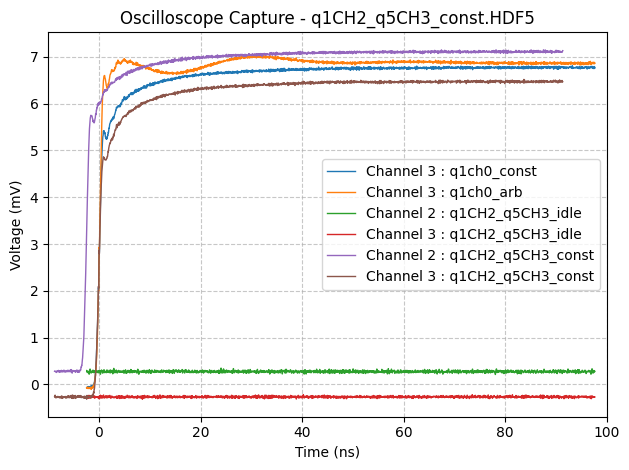

In [2]:
# --- Example Execution ---
directory = 'ffch_data_july2026'
file_list = ['q1ch0_const', 'q1ch0_arb', 'q1CH2_q5CH3_idle', 'q1CH2_q5CH3_const'] 

for file_name in file_list:
    file_path = fr'{directory}\{file_name}.HDF5'
    print(f"\nProcessing: {file_name}")
    
    # Setting plot=True will open a chart for each file automatically
    time_data, voltage_matrix = get_vt(file_path, plot=True)
    
    print(f"-> Shape of voltage matrix: {voltage_matrix.shape} (Rows = Channels, Cols = Samples)")
    print(f"-> Time Range: {time_data[0]:.2f} ns to {time_data[-1]:.2f} ns")


Processing: q1CH2_q5CH3_idle
-> Shape of voltage matrix: (2, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -2.41 ns to 97.64 ns

Processing: q5CH2_q1CH3_idle
-> Shape of voltage matrix: (2, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -8.73 ns to 91.32 ns


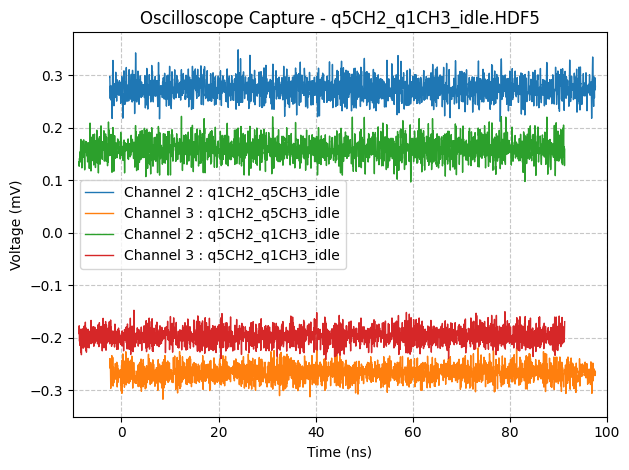

In [3]:
# --- Example Execution ---
directory = 'ffch_data_july2026'
file_list = ['q1CH2_q5CH3_idle', 'q5CH2_q1CH3_idle'] 

for file_name in file_list:
    file_path = fr'{directory}\{file_name}.HDF5'
    print(f"\nProcessing: {file_name}")
    
    # Setting plot=True will open a chart for each file automatically
    time_data, voltage_matrix = get_vt(file_path, plot=True)
    
    print(f"-> Shape of voltage matrix: {voltage_matrix.shape} (Rows = Channels, Cols = Samples)")
    print(f"-> Time Range: {time_data[0]:.2f} ns to {time_data[-1]:.2f} ns")


Processing: q1CH2_q5CH3_const

--- Rise Time Analysis (20.0% Threshold) ---
Channel 0: Rise Time = -2.839 ns
Channel 1: Rise Time = -0.274 ns

--- Channel Deltas (Relative to Channel 0) ---
Ch1 - Ch0 Delta: +2.566 ns
-> Shape of voltage matrix: (2, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -8.73 ns to 91.32 ns

Processing: q5CH2_q1CH3_const

--- Rise Time Analysis (20.0% Threshold) ---
Channel 0: Rise Time = 1.873 ns
Channel 1: Rise Time = -0.492 ns

--- Channel Deltas (Relative to Channel 0) ---
Ch1 - Ch0 Delta: -2.366 ns
-> Shape of voltage matrix: (2, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -8.73 ns to 91.32 ns


(-10.0, 10.0)

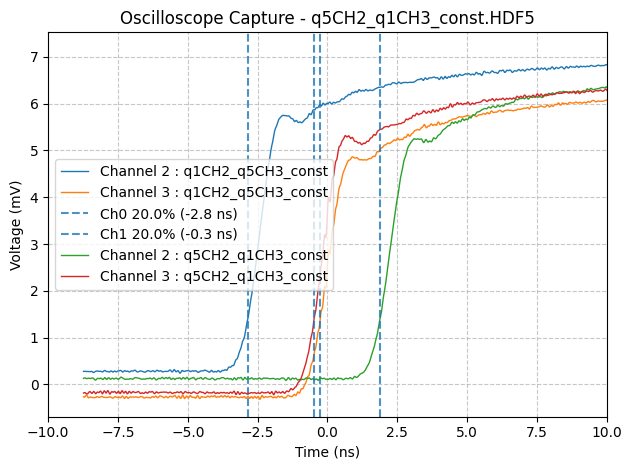

In [4]:
# --- Example Execution ---
directory = 'ffch_data_july2026'
file_list = ['q1CH2_q5CH3_const', 'q5CH2_q1CH3_const'] 

for file_name in file_list:
    file_path = fr'{directory}\{file_name}.HDF5'
    print(f"\nProcessing: {file_name}")
    
    # Setting plot=True will open a chart for each file automatically
    time_data, voltage_matrix = get_vt(file_path, plot=True)
    rise_time = get_rise_time(voltage_matrix, time_data)
    
    print(f"-> Shape of voltage matrix: {voltage_matrix.shape} (Rows = Channels, Cols = Samples)")
    print(f"-> Time Range: {time_data[0]:.2f} ns to {time_data[-1]:.2f} ns")

plt.xlim([-10,10])


Processing: q1CH2_q5CH3_arb
-> Shape of voltage matrix: (2, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -8.73 ns to 91.32 ns

Processing: q5CH2_q1CH3_arb
-> Shape of voltage matrix: (2, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -8.73 ns to 91.32 ns


(-10.0, 10.0)

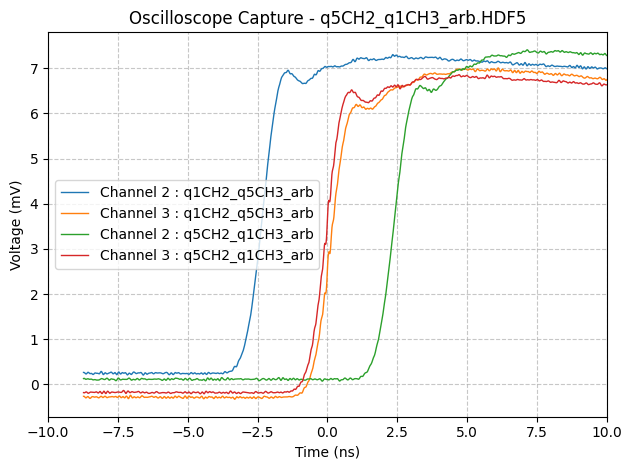

In [5]:
# --- Example Execution ---
directory = 'ffch_data_july2026'
file_list = ['q1CH2_q5CH3_arb', 'q5CH2_q1CH3_arb']

for file_name in file_list:
    file_path = fr'{directory}\{file_name}.HDF5'
    print(f"\nProcessing: {file_name}")
    
    # Setting plot=True will open a chart for each file automatically
    time_data, voltage_matrix = get_vt(file_path, plot=True)
    
    print(f"-> Shape of voltage matrix: {voltage_matrix.shape} (Rows = Channels, Cols = Samples)")
    print(f"-> Time Range: {time_data[0]:.2f} ns to {time_data[-1]:.2f} ns")

plt.xlim([-10,10])


Processing: NothingCH2_NothingCH3
-> Shape of voltage matrix: (2, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -8.73 ns to 91.32 ns

Processing: NO_CABLES_NothingCH2_NothingCH3
-> Shape of voltage matrix: (2, 32017) (Rows = Channels, Cols = Samples)
-> Time Range: -8.73 ns to 91.32 ns


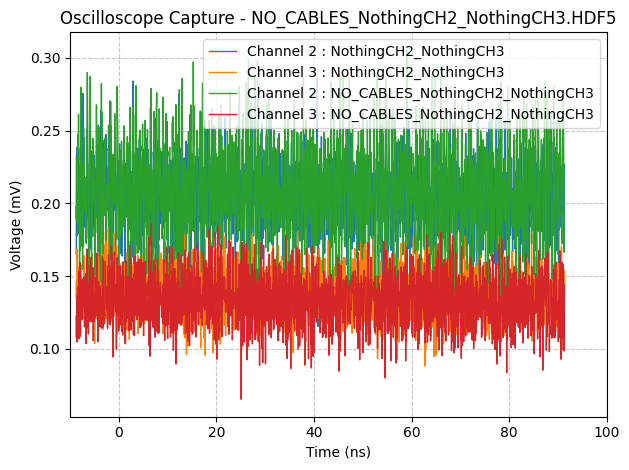

In [6]:
# --- Example Execution ---
directory = 'ffch_data_july2026'
file_list = ['NothingCH2_NothingCH3', 'NO_CABLES_NothingCH2_NothingCH3',] 

for file_name in file_list:
    file_path = fr'{directory}\{file_name}.HDF5'
    print(f"\nProcessing: {file_name}")
    
    # Setting plot=True will open a chart for each file automatically
    time_data, voltage_matrix = get_vt(file_path, plot=True)
    
    print(f"-> Shape of voltage matrix: {voltage_matrix.shape} (Rows = Channels, Cols = Samples)")
    print(f"-> Time Range: {time_data[0]:.2f} ns to {time_data[-1]:.2f} ns")

In [7]:
time_data[1] - time_data[0]

np.float64(0.003124999999998934)

In [11]:
plt.show()


Processing: q1CH2_driveCH3_DIRECT_TEST_NO_AVG_TEST
-> Shape of voltage matrix: (2, 400003) (Rows = Channels, Cols = Samples)
-> Time Range: -7331.23 ns to 12668.87 ns


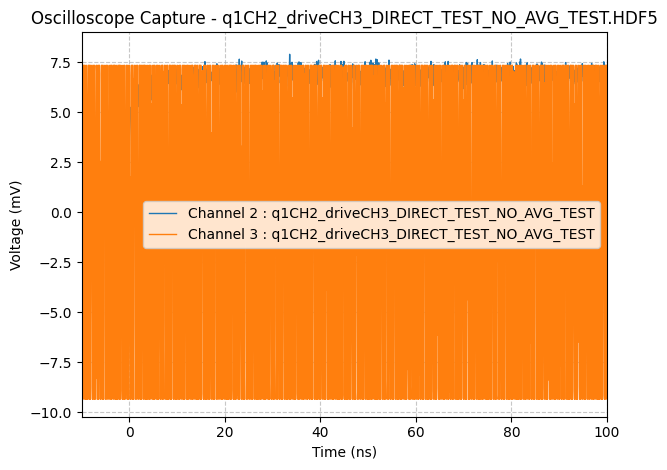

In [12]:
directory = 'ffch_data_july2026'
file_list = ['q1CH2_driveCH3_DIRECT_TEST_NO_AVG_TEST']

for file_name in file_list:
    file_path = fr'{directory}\{file_name}.HDF5'
    print(f"\nProcessing: {file_name}")
    
    # Setting plot=True will open a chart for each file automatically
    time_data, voltage_matrix = get_vt(file_path, plot=True)
    
    print(f"-> Shape of voltage matrix: {voltage_matrix.shape} (Rows = Channels, Cols = Samples)")
    print(f"-> Time Range: {time_data[0]:.2f} ns to {time_data[-1]:.2f} ns")